In [62]:
def results_files(model):
    return [
        f"{model}/{model}-1_error.out",
        f"{model}/{model}-2_error.out",
        f"{model}/{model}-5_error.out",
    ]

bert_results = results_files("bert")
bert_kg_gat_results = results_files("bert_kg_gat")
bert_kg_gcn_results = results_files("bert_kg_gcn")
bert_results = results_files("bert")
lstm_results = results_files("lstm")
textcnn_results = results_files("textcnn")
declare_results = results_files("declare")

results = sum(
    [
        results_files("noise"),
        results_files("bert"),
        results_files("bert_kg_gat"),
        results_files("bert_kg_gcn"),
        results_files("bert"),
        results_files("lstm"),
        results_files("textcnn"),
        results_files("declare"),
        results_files("get"),
        results_files("mac"),
    ], []
)

In [63]:
# Read all lines of each one
results_lines = []
for result in results:
    with open(result, "r") as f:
        lines = f.readlines()
    results_lines.append(lines)

In [ ]:
import ast

# Get first runs for each of the experiments
results_main = []
results_runs = []
for experiment_name, result in zip(results, results_lines):
    # super ugly logic to account for our compute limitations on different models
    runs_to_consider = 5 if "textcnn" in experiment_name else 1
    runs_to_consider = 2 if "lstm" in experiment_name else runs_to_consider
    runs_to_consider = 5 if "noise" in experiment_name else runs_to_consider
    runs_to_consider = 4 if "bert" in experiment_name else runs_to_consider
    n_runs_so_far = -1
    runs = []
    run = []
    for idx in range(len(result)):
        line = result[idx]
        # only see first n runs
        if "run" in line:
            n_runs_so_far += 1
            if run:
                runs.append(run)
                run = []

        if n_runs_so_far >= 0:
            # if line.startswith("epoch") or line.startswith("noise"):
            if line.startswith("post-training") or line.startswith("noise"):
                split_string = "metrics:"
                if "metrics:" not in line:
                    split_string = "best"
                line = line.split(split_string)[1].strip()
                line = ast.literal_eval(line)
                run.append(line)
                # print(line)
        #if f"run {runs_to_consider+1}" in line:
        #    break
    if run:
        runs.append(run)
    results_main.append(result[:idx])
    results_runs.append(runs)


In [65]:
"""
# Get best f1 for each of the experiments
import ast
final_results = []
for result in results_main:
    best_result_f1 = {"f1": 0}
    for line in result:
        if line.startswith("epoch") or line.startswith("noise"):
            line = line.split("metrics:")[1].strip()
            line = ast.literal_eval(line)
            if line["f1"] >= best_result_f1["f1"]:
                best_result_f1 = line
    final_results.append(best_result_f1)
"""

def get_run_max_f1(run):
    best_result_f1 = {"f1": 0}
    for line in run:
        if "f1" in line and line["f1"] >= best_result_f1["f1"]:
            best_result_f1 = line
    return best_result_f1

results_runs_best_f1s = []
for result in results_runs:
    result = [get_run_max_f1(run) for run in result]
    results_runs_best_f1s.append(result)

def pull_stats(_arr, use_means=True):
    import numpy as np
    if use_means:
        vals = {}
        for a in _arr:
            for k in a:
                if k not in vals: vals[k] = []
                vals[k].append(a[k])
        means = {}
        for k in vals:
            means[k] = np.mean(vals[k])
        return means
    else:
        arr = [a["f1"] for a in _arr]
        if arr:
            mean = np.mean(arr)
            std = np.std(arr)
            _max = np.max(arr)
            _max_idx = arr.index(_max)
            return {"mean": mean, "std": std, "max": _max, **_arr[_max_idx]}
    return {"f1": 0, "std": 0, "max": 0}

final_results = []
for result in results_runs_best_f1s:
    final_results.append(pull_stats(result))

In [66]:
dictionary_results = {}
for experiment_name, experiment_results in zip(results, final_results):
    dictionary_results[experiment_name] = experiment_results

In [67]:
#for k in dictionary_results:
#    print(f"{k}: {dictionary_results[k]}")

import pprint
pprint.PrettyPrinter(indent=4).pprint(dictionary_results)

{   'bert/bert-1_error.out': {   'f1': np.float64(0.22959619377306173),
                                 'f1_macro': np.float64(0.6070854736011995),
                                 'f1_micro': np.float64(0.992959051724138),
                                 'prec_macro': np.float64(0.6198517316017316),
                                 'prec_micro': np.float64(0.992959051724138),
                                 'rec_macro': np.float64(0.6130297733026246),
                                 'rec_micro': np.float64(0.992959051724138)},
    'bert/bert-2_error.out': {   'f1': np.float64(0.29050010782135194),
                                 'f1_macro': np.float64(0.691362851081177),
                                 'f1_micro': np.float64(0.9902271551724139),
                                 'prec_macro': np.float64(0.614435),
                                 'prec_micro': np.float64(0.9902271551724139),
                                 'rec_macro': np.float64(0.6427898889474429),
           

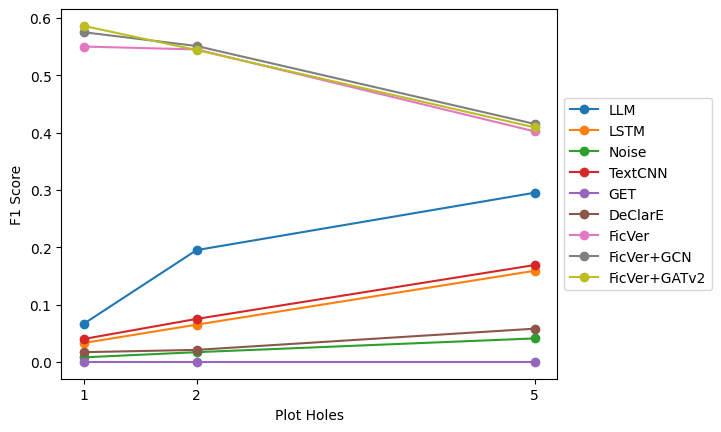

In [73]:
import matplotlib.pyplot as plt

graph_lines = [
    "noise",
    "bert",
    "bert_kg_gat",
    "bert_kg_gcn",
    "bert",
    "lstm",
    "textcnn",
    "declare",
    "get",
    "mac",
    "llm"
]
order = ["1_error", "2_error", "5_error"]
def index_of_value(experiment_name):
    for i, x in enumerate(order):
        if x in experiment_name:
            return i
# graph_line_values = {k: [0, 0, 0] for k in graph_lines}
graph_line_values = {}
# for experiment_name in dictionary_results:
#     for graph_line in graph_lines:
#         if graph_line in experiment_name:
#             # print(experiment_name)
#             # print(dictionary_results[experiment_name])
#             if experiment_name not in dictionary_results or "f1" not in dictionary_results[experiment_name]:
#                 continue
#             graph_line_values[graph_line][index_of_value(experiment_name)] = dictionary_results[experiment_name]["f1"]

# Hardcoded LLM metrics (F1-T) from llm
graph_line_values["LLM"] = [0.0666, 0.1950, 0.2951]

# Hardcoded LSTM metrics since they're broke
graph_line_values["LSTM"] = [0.033, 0.065, 0.159]

# Hardcoded metrics from LaTeX table (F1-T)
graph_line_values["Noise"] = [0.008, 0.017, 0.041]
graph_line_values["TextCNN"] = [0.040, 0.075, 0.169]
graph_line_values["GET"] = [0.000, 0.000, 0.000]
graph_line_values["DeClarE"] = [0.017, 0.021, 0.058]
# FicVer family
graph_line_values["FicVer"] = [0.550, 0.545, 0.402]           # FicVer
graph_line_values["FicVer+GCN"] = [0.575, 0.551, 0.415]    # FicVer+GCN
graph_line_values["FicVer+GATv2"] = [0.586, 0.544, 0.409]    # FicVer+GATv2
# MAC
# graph_line_values["mac"] = [0.000, 0.000, 0.000]

fig, ax = plt.subplots()
x = [1, 2, 5]
for graph_line in graph_line_values:
    y = graph_line_values[graph_line]
    ax.plot(x, y, "o-", label=graph_line)

# Set the labels and title
ax.set_xlabel("Plot Holes")
ax.set_xticks(x)
ax.set_ylabel("F1 Score")

# Add a legend
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))


# Show the graph
plt.show()